In [7]:
import sys, os
import sqlite3
import pandas as pd
from dotenv import load_dotenv
load_dotenv()
sys.path.append(os.path.abspath('..'))

from src.data_loader import load_csv, load_sqlite, load_postgres, save_to_sqlite, create_engine

df = load_csv('../data/Walmart.csv')
# print("CSV preview:")
# print(df.head())

# --- Load SQLite ---
# Connect/create SQLite DB
conn = sqlite3.connect('../data/walmart.db')

# Save DataFrame as a table
save_to_sqlite(df)

# Test reading
df_postgres = pd.read_sql("SELECT * FROM sales LIMIT 5;", conn)
#print(df_postgres.head())
    
conn.close()

# --- Load PostgreSQL (if available) ---
# Replace with your own engine URL
engine_url = f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
df_pg = load_postgres("SELECT * FROM sales LIMIT 5;", engine_url)
print("PostgreSQL preview:")
print(df_pg.head())

PostgreSQL preview:
   store        date  weekly_sales  holiday_flag  temperature  fuel_price  \
0      1  2010-02-05    1643690.90         False        42.31        2.57   
1      1  2010-02-12    1641957.44          True        38.51        2.55   
2      1  2010-02-19    1611968.17         False        39.93        2.51   
3      1  2010-02-26    1409727.59         False        46.63        2.56   
4      1  2010-03-05    1554806.68         False        46.50        2.63   

       cpi  unemployment  
0  211.096         8.106  
1  211.242         8.106  
2  211.289         8.106  
3  211.320         8.106  
4  211.350         8.106  


#### Do holidays have higher sales?

In [35]:
query = """
SELECT 
    holiday_flag, 
    AVG(weekly_sales) AS avg_weekly_sales
FROM sales
GROUP BY  holiday_flag
ORDER BY avg_weekly_sales DESC;
"""
df_result1 = load_postgres(query, engine_url)
print("Query result preview:")
print(df_result1)
print(df_result1['avg_weekly_sales'][0]-df_result1['avg_weekly_sales'][1])

Query result preview:
   holiday_flag  avg_weekly_sales
0          True      1.122888e+06
1         False      1.041256e+06
81631.51214670017


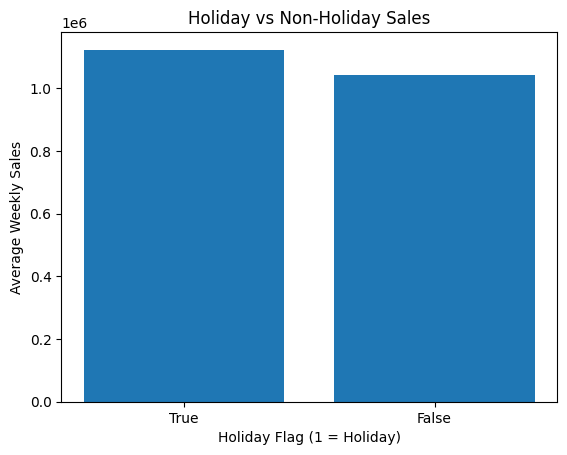

In [33]:
import matplotlib.pyplot as plt, numpy as np

plt.bar(df_result1['holiday_flag'].astype(str), df_result1['avg_weekly_sales'])
plt.xlabel("Holiday Flag (1 = Holiday)")
plt.ylabel("Average Weekly Sales")
plt.title("Holiday vs Non-Holiday Sales")
plt.show()

#### Does the effect vary by store?

In [36]:
query = """
SELECT 
    store, 
    AVG(CASE WHEN holiday_flag THEN weekly_sales END) AS avg_holiday_sales,
    AVG(CASE WHEN NOT holiday_flag THEN weekly_sales END) AS avg_non_holiday_sales,
    AVG(CASE WHEN holiday_flag THEN weekly_sales END) - AVG(CASE WHEN NOT holiday_flag THEN weekly_sales END) AS sales_diff
FROM sales
GROUP BY store
ORDER BY sales_diff DESC;
"""
df_result = load_postgres(query, engine_url)
print("Query result preview:")
print(df_result)

Query result preview:
    store  avg_holiday_sales  avg_non_holiday_sales     sales_diff
0      10        2113755.949           1.883309e+06  230446.517421
1      28        1478244.605           1.311889e+06  166355.623571
2      35        1074348.457           9.080992e+05  166249.302789
3       2        2079266.900           1.914209e+06  165058.088120
4       4        2243102.624           2.083556e+06  159546.780842
5      20        2249035.081           2.097048e+06  151986.647541
6      19        1577046.734           1.435071e+06  141976.096707
7      12        1138140.420           9.992919e+05  138848.495564
8      24        1475098.251           1.347857e+06  127240.816639
9      27        1892299.278           1.766413e+06  125886.314842
10      6        1680907.927           1.555993e+06  124915.059556
11      1        1665747.656           1.546957e+06  118790.270361
12     13        2113043.806           1.995393e+06  117650.830511
13     31        1500026.030           1

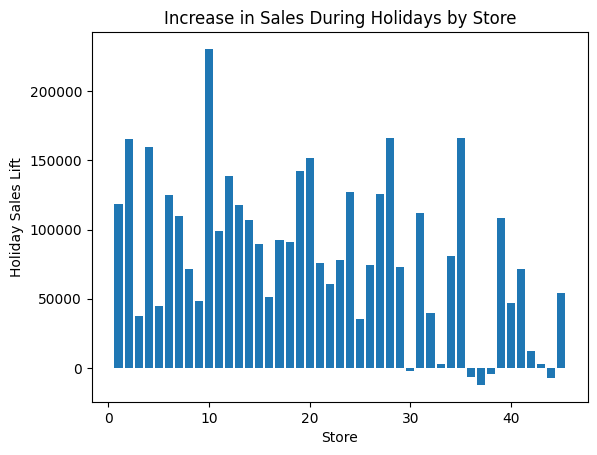

In [30]:
plt.bar(df_result['store'], df_result['sales_diff'])
plt.xlabel("Store")
plt.ylabel("Holiday Sales Lift")
plt.title("Increase in Sales During Holidays by Store")
plt.show()